# RFUAV Experiment 1 — Google Colab GPU Training

This notebook is a clean starter workflow for using Google Colab with the RFUAV dataset.

The goal of this notebook is to:

    Check whether Colab GPU is available.
    Mount Google Drive so model checkpoints are saved permanently.
    Install the required Python packages.
    Download a small RFUAV subset from Hugging Face.
    Arrange the dataset into a PyTorch ImageFolder format.
    Train a simple ResNet18 classifier on RF spectrogram images.
    Save the best model and generate a confusion matrix.


## 1. Enable GPU in Colab

Before running the notebook, go to:

Runtime → Change runtime type → Hardware accelerator → T4 GPU

Then run the cell below. If CUDA is available, PyTorch can use the GPU.

In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected")


CUDA available: True
GPU: Tesla T4


## 2. Mount Google Drive

Colab temporary storage under `/content/` disappears when the runtime disconnects.

Google Drive storage under `/content/drive/MyDrive/` is permanent, so we save models, logs, and images there.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Failed to issue request POST https://colab.research.google.com/tun/m/credentials-propagation/gpu-t4-s-kkb-ass1a2-3qwv7xtcqhip0?authtype=dfs_ephemeral&version=2&dryrun=false&propagate=true&record=false&authuser=0: Bad Request
Response body: 
<!DOCTYPE html>
<html lang=en>
  <meta charset=utf-8>
  <meta name=viewport content="initial-scale=1, minimum-scale=1, width=device-width">
  <title>Error 400 (Bad Request)!!1</title>
  <style>
    *{margin:0;padding:0}html,code{font:15px/22px arial,sans-serif}html{background:#fff;color:#222;padding:15px}body{margin:7% auto 0;max-width:390px;min-height:180px;padding:30px 0 15px}* > body{background:url(//www.google.com/images/errors/robot.png) 100% 5px no-repeat;padding-right:205px}p{margin:11px 0 22px;overflow:hidden}ins{color:#777;text-decoration:none}a img{border:0}@media screen and (max-width:772px){body{background:none;margin-top:0;max-width:none;padding-right:0}}#logo{background:url(//www.google.com/images/logos/errorpage/error_lo

## 3. Create project folders

This notebook uses two main locations:

- `/content/dataset` — fast temporary training data location.
- `/content/drive/MyDrive/RFUAV_Project` — permanent project folder for models and results.


In [3]:
import os

PROJECT_DIR = "/content/drive/MyDrive/RFUAV_Project"
DATASET_DIR = "/content/dataset"
RAW_DOWNLOAD_DIR = "/content/RFUAV_data"

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(DATASET_DIR, exist_ok=True)
os.makedirs(RAW_DOWNLOAD_DIR, exist_ok=True)

print("Project folder:", PROJECT_DIR)
print("Dataset folder:", DATASET_DIR)
print("Raw download folder:", RAW_DOWNLOAD_DIR)


Project folder: /content/drive/MyDrive/RFUAV_Project
Dataset folder: /content/dataset
Raw download folder: /content/RFUAV_data


## 4. Check PyTorch and CUDA versions

First, install all the nessessary library.

The `!` symbol means the command is executed as a Linux terminal command, not Python.

This is important because commands such as `pip install`, `mkdir`, and `huggingface-cli` are shell commands.

`
!pip install -U huggingface_hub
`

`
!pip install scikit-learn matplotlib pandas tqdm pillow pyyaml
`
This confirms that PyTorch is installed and whether it can see the GPU.

In [4]:
import torch
import torchvision

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA:", torch.cuda.is_available())

Torch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
CUDA: True


## 5. Download a small RFUAV subset

This cell downloads only three classes:

- `YunZhuo-H12`
- `YunZhuo-H16`
- `YunZhuo-H30`

Optionally, try to classify all 37 UAV classes. 

This is a good first experiment because it is much smaller than the full RFUAV dataset.

The `%%bash` line makes the whole cell run as a Linux terminal script. Without `%%bash` or `!`, Colab will treat `huggingface-cli` as Python and produce a `SyntaxError`.

In [11]:
%%bash

set -e

mkdir -p /content/RFUAV_data

hf download kitofrank/RFUAV \
  --repo-type dataset \
  --local-dir /content/RFUAV_data \
  --include "ImageSet-AllDrones-MatlabPipeline/train/YunZhuo-H12/*" \
  --include "ImageSet-AllDrones-MatlabPipeline/valid/YunZhuo-H12/*" \
  --include "ImageSet-AllDrones-MatlabPipeline/train/YunZhuo-H16/*" \
  --include "ImageSet-AllDrones-MatlabPipeline/valid/YunZhuo-H16/*" \
  --include "ImageSet-AllDrones-MatlabPipeline/train/YunZhuo-H30/*" \
  --include "ImageSet-AllDrones-MatlabPipeline/valid/YunZhuo-H30/*"


✓ Downloaded
  path: /content/RFUAV_data


Number of files in the repo is unreliable. Using `list_repo_tree` to ensure all files are listed.
Fetching ... files: 1355it [00:00, 1616.57it/s]


In [5]:
# %%bash

# set -e

# mkdir -p /content/RFUAV_data

# hf download kitofrank/RFUAV \
#   --repo-type dataset \
#   --local-dir /content/RFUAV_data \
#   --include "ImageSet-AllDrones-MatlabPipeline/train/*/*" \
#   --include "ImageSet-AllDrones-MatlabPipeline/valid/*/*" \
#   --exclude "*.pt" \
#   --exclude "*.pth" \
#   --exclude "*.onnx"

# !du -sh /content/RFUAV_data

Process is terminated.


## 6. Check class counts

This is a quick sanity check.

You want each class folder to contain image files. If a class shows `0`, the folder path is probably wrong.


In [10]:
%%bash

echo "Train set:"
find /content/dataset/train -mindepth 2 -maxdepth 2 -type f | sed 's|/content/dataset/train/||' | cut -d/ -f1 | sort | uniq -c

echo ""
echo "Validation set:"
find /content/dataset/valid -mindepth 2 -maxdepth 2 -type f | sed 's|/content/dataset/valid/||' | cut -d/ -f1 | sort | uniq -c


Train set:

Validation set:


find: ‘/content/dataset/train’: No such file or directory
find: ‘/content/dataset/valid’: No such file or directory


## 7. Load the dataset with PyTorch

`ImageFolder` automatically assigns a numeric label to each class folder.

Example:

```text
YunZhuo-H12 → 0
YunZhuo-H16 → 1
YunZhuo-H30 → 2
```

The exact mapping is printed below.


In [21]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_dir = "/content/dataset/train"
valid_dir = "/content/dataset/valid"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
valid_dataset = datasets.ImageFolder(valid_dir, transform=transform)

print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)
print("Train images:", len(train_dataset))
print("Valid images:", len(valid_dataset))

Classes: ['YunZhuo-H12', 'YunZhuo-H16', 'YunZhuo-H30']
Class mapping: {'YunZhuo-H12': 0, 'YunZhuo-H16': 1, 'YunZhuo-H30': 2}
Train images: 406
Valid images: 949


## 8. Train a ResNet18 classifier

This is a simple supervised baseline.

The model learns to classify RF spectrogram images into the three selected UAV/controller classes.

Main settings:

- Model: `ResNet18`
- Input size: `224 × 224`
- Batch size: `32`
- Epochs: `5`
- Optimizer: `Adam`
- Loss: `CrossEntropyLoss`

Outputs saved to Google Drive:

- `best.pt` — best validation model
- `last.pt` — final model after training
- `history.csv` — training/validation accuracy log
- `classes.json` — class label mapping


In [22]:
import os
import json
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

# -------------------------
# Basic configuration
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

train_dir = "/content/dataset/train"
valid_dir = "/content/dataset/valid"
save_dir = "/content/drive/MyDrive/RFUAV_Project/models/resnet18_yunzhuo_3class"
os.makedirs(save_dir, exist_ok=True)

batch_size = 32
epochs = 5
learning_rate = 0.001

# -------------------------
# Data loading
# -------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
valid_dataset = datasets.ImageFolder(valid_dir, transform=transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

num_classes = len(train_dataset.classes)
print("Classes:", train_dataset.classes)
print("Number of classes:", num_classes)

# Save class mapping for later inference
with open(os.path.join(save_dir, "classes.json"), "w") as f:
    json.dump(train_dataset.class_to_idx, f, indent=2)

# -------------------------
# Model
# -------------------------
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# -------------------------
# Training loop
# -------------------------
best_acc = 0.0
history = []

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs} Train"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss / train_total
    train_acc = train_correct / train_total

    model.eval()
    valid_loss = 0.0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():
        for images, labels in tqdm(valid_loader, desc=f"Epoch {epoch + 1}/{epochs} Valid"):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            valid_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            valid_correct += (preds == labels).sum().item()
            valid_total += labels.size(0)

    valid_loss = valid_loss / valid_total
    valid_acc = valid_correct / valid_total

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "valid_loss": valid_loss,
        "valid_acc": valid_acc,
    }
    history.append(row)

    print(
        f"Epoch {epoch + 1}: "
        f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
        f"Valid Loss={valid_loss:.4f}, Valid Acc={valid_acc:.4f}"
    )

    if valid_acc > best_acc:
        best_acc = valid_acc
        torch.save(model.state_dict(), os.path.join(save_dir, "best.pt"))
        print("Saved new best model")

# Save final model and training history
torch.save(model.state_dict(), os.path.join(save_dir, "last.pt"))
pd.DataFrame(history).to_csv(os.path.join(save_dir, "history.csv"), index=False)

print("Training finished")
print("Best validation accuracy:", best_acc)
print("Saved results to:", save_dir)


Using device: cuda
Classes: ['YunZhuo-H12', 'YunZhuo-H16', 'YunZhuo-H30']
Number of classes: 3


Epoch 1/5 Valid: 100%|██████████| 30/30 [00:33<00:00,  1.12s/it]


Epoch 1: Train Loss=0.5912, Train Acc=0.7931, Valid Loss=3.0441, Valid Acc=0.3193
Saved new best model


Epoch 2/5 Valid: 100%|██████████| 30/30 [00:34<00:00,  1.15s/it]


Epoch 2: Train Loss=0.0208, Train Acc=0.9975, Valid Loss=4.0608, Valid Acc=0.3193


...

Epoch 3: Train Loss=0.0644, Train Acc=0.9754, Valid Loss=0.9905, Valid Acc=0.7450
Saved new best model


Epoch 4/5 Valid: 100%|██████████| 30/30 [00:32<00:00,  1.08s/it]


Epoch 4: Train Loss=0.0338, Train Acc=0.9901, Valid Loss=0.0215, Valid Acc=0.9937
Saved new best model


Epoch 5/5 Valid: 100%|██████████| 30/30 [00:32<00:00,  1.08s/it]


Epoch 5: Train Loss=0.0274, Train Acc=0.9926, Valid Loss=0.0112, Valid Acc=0.9958
Saved new best model
Training finished
Best validation accuracy: 0.9957850368809273
Saved results to: /content/drive/MyDrive/RFUAV_Project/models/resnet18_yunzhuo_3class


## 9. Preview a few spectrogram images

This helps confirm that the dataset is being loaded correctly.

The images are RF spectrogram-style images, so they may look like heatmaps or frequency-time patterns.

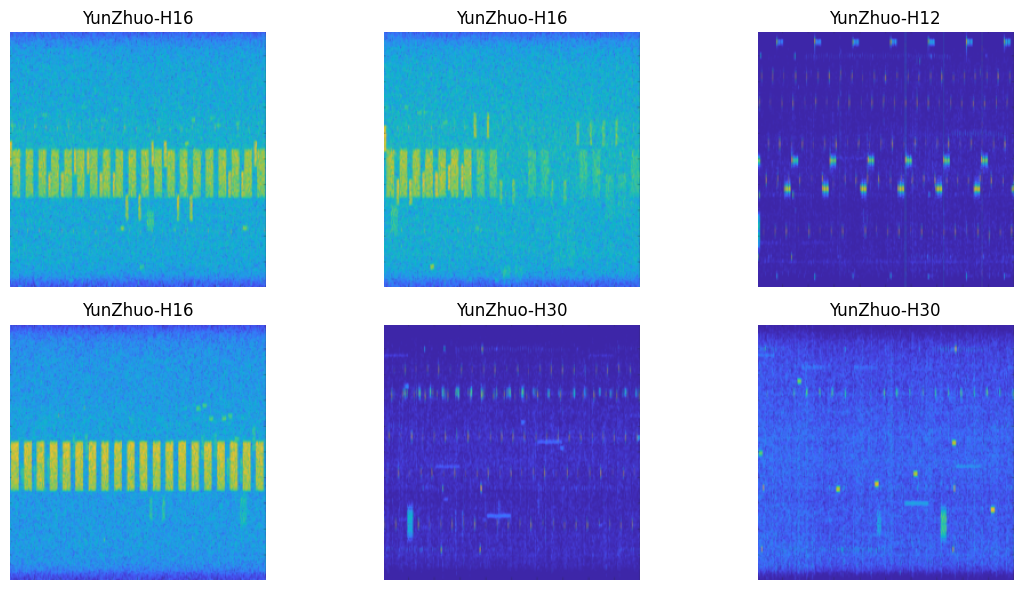

In [23]:
import matplotlib.pyplot as plt
import random

num_images = min(6, len(train_dataset))
indices = random.sample(range(len(train_dataset)), num_images)

plt.figure(figsize=(12, 6))
for i, idx in enumerate(indices):
    image, label = train_dataset[idx]
    image_np = image.permute(1, 2, 0).numpy()

    plt.subplot(2, 3, i + 1)
    plt.imshow(image_np)
    plt.title(train_dataset.classes[label])
    plt.axis("off")

plt.tight_layout()
plt.show()


## 10. Plot training curves

This shows whether the model is learning or overfitting.

Useful signs:

- Training accuracy increases → the model is learning the training set.
- Validation accuracy increases → the model generalizes better.
- Training accuracy high but validation accuracy low → possible overfitting.
- Very high validation accuracy too quickly → check for possible data leakage or duplicate files.


,epoch,train_loss,train_acc,valid_loss,valid_acc
0,1,0.591240,0.793103,3.044083,0.319283
1,2,0.020782,0.997537,4.060761,0.319283
2,3,0.064386,0.975369,0.990483,0.744995
3,4,0.033845,0.990148,0.021522,0.993678
4,5,0.027436,0.992611,0.011174,0.995785


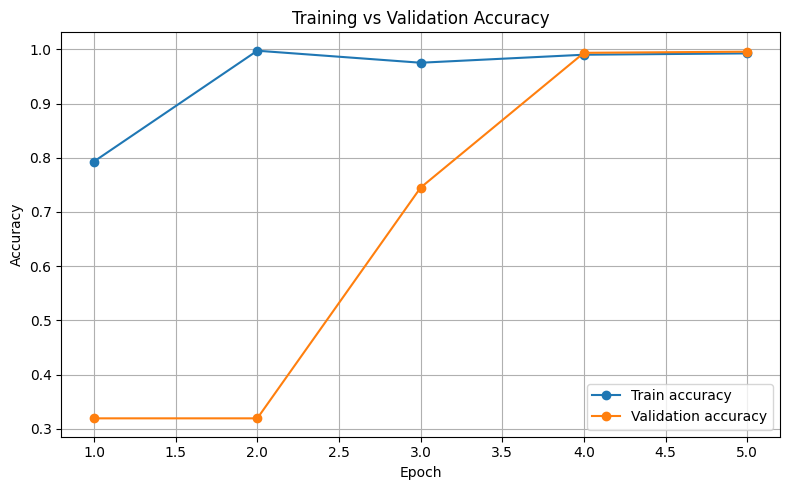

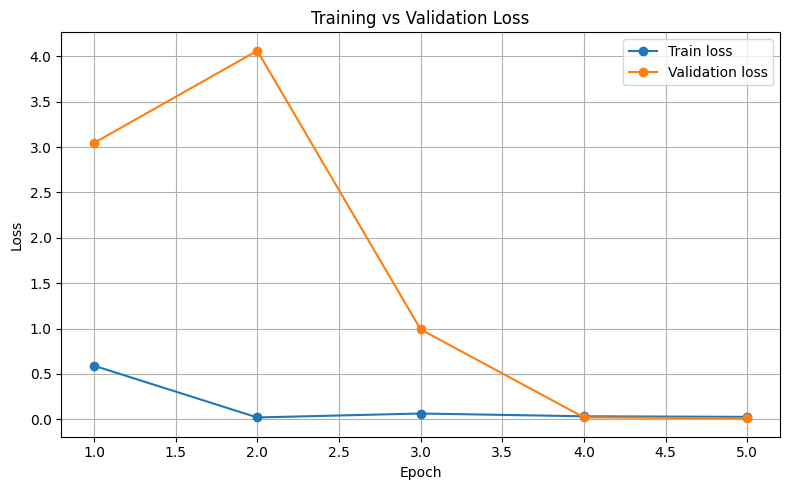

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import os

save_dir = "/content/drive/MyDrive/RFUAV_Project/models/resnet18_yunzhuo_3class"
history_path = os.path.join(save_dir, "history.csv")

history_df = pd.read_csv(history_path)
display(history_df)

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], marker="o", label="Train accuracy")
plt.plot(history_df["epoch"], history_df["valid_acc"], marker="o", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "accuracy_curve.png"))
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
plt.plot(history_df["epoch"], history_df["valid_loss"], marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "loss_curve.png"))
plt.show()


## 11. Confusion matrix and classification report

The confusion matrix shows which classes are being confused with each other.

For example, if many `YunZhuo-H12` samples are predicted as `YunZhuo-H16`, then the model may be learning features that are not strong enough to separate those two classes.


              precision    recall  f1-score   support

 YunZhuo-H12       1.00      1.00      1.00       218
 YunZhuo-H16       1.00      0.99      1.00       428
 YunZhuo-H30       0.99      1.00      0.99       303

    accuracy                           1.00       949
   macro avg       1.00      1.00      1.00       949
weighted avg       1.00      1.00      1.00       949



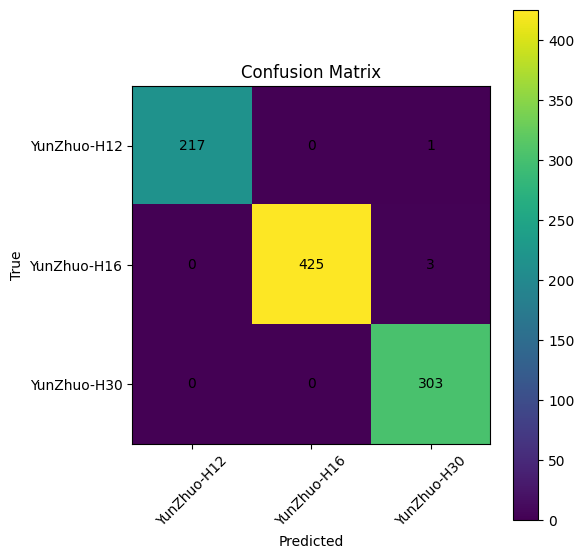

Saved confusion matrix to: /content/drive/MyDrive/RFUAV_Project/models/resnet18_test/confusion_matrix.png


In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=valid_dataset.classes))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(np.arange(len(valid_dataset.classes)), valid_dataset.classes, rotation=45)
plt.yticks(np.arange(len(valid_dataset.classes)), valid_dataset.classes)
plt.colorbar()

for i in range(len(valid_dataset.classes)):
    for j in range(len(valid_dataset.classes)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()

save_path = "/content/drive/MyDrive/RFUAV_Project/models/resnet18_test/confusion_matrix.png"
plt.savefig(save_path)
plt.show()

print("Saved confusion matrix to:", save_path)

## 12. Optional: test one image manually

Change `image_path` to any image from the validation set.

This is useful after training because it shows the predicted class for a single spectrogram.


Testing image: /content/dataset/valid/YunZhuo-H16/yunzhuo-H16244.jpg
Predicted class: YunZhuo-H16
Confidence: 0.999981164932251


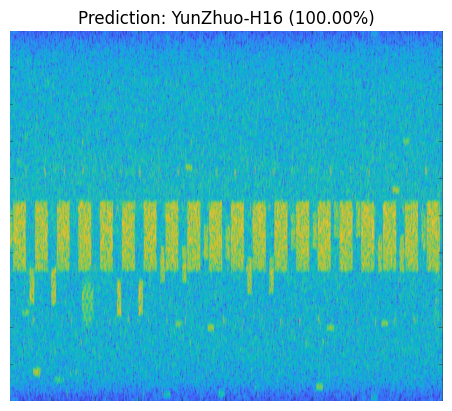

In [29]:
from PIL import Image
import torch
import os

# Pick one validation image automatically
image_path = None
for root, dirs, files in os.walk("/content/dataset/valid"):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            image_path = os.path.join(root, file)
            break
    if image_path is not None:
        break

print("Testing image:", image_path)

image = Image.open(image_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(input_tensor)
    probabilities = torch.softmax(output, dim=1)
    confidence, predicted_idx = torch.max(probabilities, 1)

predicted_class = valid_dataset.classes[predicted_idx.item()]
print("Predicted class:", predicted_class)
print("Confidence:", confidence.item())

plt.imshow(image)
plt.title(f"Prediction: {predicted_class} ({confidence.item():.2%})")
plt.axis("off")
plt.show()


In [34]:
from pathlib import Path
from PIL import Image
import imagehash
from collections import defaultdict

train_dir = Path("/content/dataset/train")
valid_dir = Path("/content/dataset/valid")

def compute_hashes(root):
    hashes = defaultdict(list)

    for path in root.rglob("*"):
        if path.is_file() and path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            try:
                img = Image.open(path).convert("RGB")
                h = imagehash.phash(img)
                cls = path.parent.name
                hashes[cls].append((h, path))
            except Exception as e:
                print("Error reading:", path, e)

    return hashes

train_hashes = compute_hashes(train_dir)
valid_hashes = compute_hashes(valid_dir)

for cls in sorted(train_hashes.keys()):
    print("=" * 60)
    print("Class:", cls)

    close_matches = []

    for vh, vpath in valid_hashes[cls]:
        for th, tpath in train_hashes[cls]:
            distance = vh - th

            # 0 = identical, <= 5 = very similar
            if distance <= 5:
                close_matches.append((distance, vpath.name, tpath.name))
                break

    print("Valid images:", len(valid_hashes[cls]))
    print("Very similar valid images found in train:", len(close_matches))

    if close_matches:
        print("Examples:")
        for item in close_matches[:10]:
            print(item)

Class: YunZhuo-H12
Valid images: 218
Very similar valid images found in train: 0
Class: YunZhuo-H16
Valid images: 428
Very similar valid images found in train: 7
Examples:
(4, 'yunzhuo-H16404.jpg', 'yunzhuo-H1665.jpg')
(4, 'yunzhuo-H16123.jpg', 'yunzhuo-H16110.jpg')
(4, 'yunzhuo-H16265.jpg', 'yunzhuo-H1665.jpg')
(2, 'yunzhuo-H16163.jpg', 'yunzhuo-H1665.jpg')
(4, 'yunzhuo-H16326.jpg', 'yunzhuo-H1665.jpg')
(4, 'yunzhuo-H16379.jpg', 'yunzhuo-H1665.jpg')
(4, 'yunzhuo-H16294.jpg', 'yunzhuo-H16120.jpg')
Class: YunZhuo-H30
Valid images: 303
Very similar valid images found in train: 0
